In [ ]:
import os
import numpy as np
import simplegrad as sg
import matplotlib.pyplot as plt

%matplotlib inline

In [ ]:
sg.seed(2026)
sg.default_dtype("float32")

if sg.cuda_is_available():
    sg.default_device("cuda:0")
else:
    sg.default_device("cpu")

In [ ]:
!curl -L -o /home/examples/cifar10.zip https://www.kaggle.com/api/v1/datasets/download/oxcdcd/cifar10
!mkdir -p /home/examples/datasets/cifar10/
!unzip -q /home/examples/cifar10.zip -d /home/examples/datasets/cifar10/
!rm -rf /home/examples/cifar10.zip

In [3]:
train_path = "../datasets/cifar10/cifar10/train/"
test_path = "../datasets/cifar10/cifar10/test/"
labels_path = "../datasets/cifar10/cifar10/labels.txt"

In [4]:
with open(labels_path) as f:
    labels = f.read().splitlines()
print(labels)
print(len(labels))

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
10


In [ ]:
def get_files_and_labels(path):
    files = []
    lbls = []
    for d in os.walk(path):
        label = os.path.basename(d[0]).split("/")[-1]
        for f in d[2]:
            files.append(os.path.join(d[0], f))
            lbls.append(labels.index(label))
    return files, np.array(lbls)

train_files, train_labels = get_files_and_labels(train_path)
test_files, test_labels = get_files_and_labels(test_path)

print(f"Train files: {len(train_files)}")
print(f"Train labels: {len(train_labels)}")
print(f"Unique train labels: {len(set(train_labels))}")

print(f"\nTest files: {len(test_files)}")
print(f"Test labels: {len(test_labels)}")
print(f"Unique test labels: {len(set(test_labels))}")

Train files: 50000
Train labels: 50000
Unique train labels: 10

Test files: 10000
Test labels: 10000
Unique test labels: 10


(32, 32, 3)
8 ship


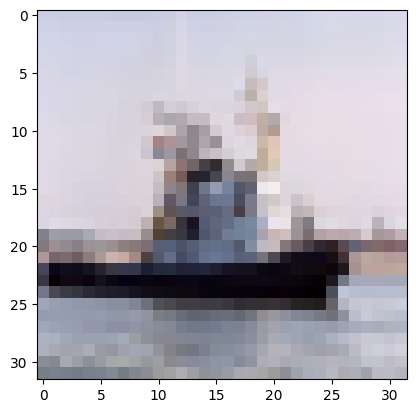

In [6]:
index = 25000
im = plt.imread(train_files[index])
print(im.shape)
print(train_labels[index], labels[train_labels[index]])
plt.imshow(im)
plt.show()


In [ ]:
def one_hot(indices: np.ndarray, num_classes: int) -> sg.Tensor:
    oh = np.zeros((len(indices), num_classes), dtype=np.float32)
    oh[np.arange(len(indices)), indices.astype(int)] = 1.0
    return sg.Tensor(oh)

# Pre-load test set once
test_imgs = sg.Tensor(
    np.array([plt.imread(f).transpose(2, 0, 1) / 255.0 for f in test_files], dtype=np.float32)
)
test_labels_oh = one_hot(test_labels, len(labels))

In [10]:
model = sg.nn.Sequential(
    sg.nn.Conv2d(3, 16, kernel_size=3, stride=1, pad_width=1),
    sg.nn.ReLU(),
    sg.nn.MaxPool2d(kernel_size=2, stride=2),
    sg.nn.Conv2d(16, 32, kernel_size=3, stride=1, pad_width=1),
    sg.nn.ReLU(),
    sg.nn.MaxPool2d(kernel_size=2, stride=2),
    sg.nn.Flatten(),
    sg.nn.Linear(32 * 8 * 8, 10)
)
model.summary()

Parameters of Sequential

Parameter            Shape           Trainable Parameters                    
------------------------------------------------------------
modules.0.weight     (16, 3, 3, 3)   432                                     
modules.0.bias       (16,)           16                                      
modules.3.weight     (32, 16, 3, 3)  4608                                    
modules.3.bias       (32,)           32                                      
modules.7.weight     (2048, 10)      20480                                   
modules.7.bias       (10,)           10                                      
------------------------------------------------------------
Total trainable parameters: 25578


In [ ]:
NUM_EPOCHS = 20
LR = 1e-3
BATCH_SIZE = 64
VAL_EVERY = 2  # run validation every N epochs
PATIENCE = 3  # early stopping: stop after this many val checks with no improvement

opt = sg.opt.AdamW(model, lr=LR, beta_1=0.9, beta_2=0.999, eps=1e-8, weight_decay=1e-2)

steps_per_epoch = len(train_files) // BATCH_SIZE
sch = sg.sch.CosineAnnealingLR(
    opt,
    T_0=NUM_EPOCHS * steps_per_epoch,
    lr_min=1e-5,
    lr_max=LR,
)

loss_fn = sg.nn.CELoss()

tr = sg.Tracker("./experiments")
tr.set_experiment("cifar10_cnn")
tr.start_run(
    name="cifar10_cnn",
    config=dict(lr=LR, batch_size=BATCH_SIZE, num_epochs=NUM_EPOCHS, optimizer="AdamW", weight_decay=1e-2, scheduler="CosineAnnealingLR"),
)

best_val_loss = float("inf")
no_improve = 0
global_step = 0
stopped_early = False

model.set_train_mode()
for epoch in range(NUM_EPOCHS):
    perm = np.random.permutation(len(train_files))
    epoch_loss, num_batches = 0.0, 0

    for i in range(0, len(train_files), BATCH_SIZE):
        idx = perm[i : i + BATCH_SIZE]
        batch_images = sg.Tensor(np.array([plt.imread(train_files[j]).transpose(2, 0, 1) / 255.0 for j in idx], dtype=np.float32))
        batch_labels_oh = one_hot(np.array([train_labels[j] for j in idx]), len(labels))

        outputs = model(batch_images)
        loss = loss_fn(outputs, batch_labels_oh)

        opt.zero_grad()
        loss.backward()
        opt.step()
        sch.step()

        tr.record("train_loss", loss.values.item(), global_step)
        epoch_loss += loss.values.item()
        num_batches += 1
        global_step += 1

    avg_loss = epoch_loss / num_batches
    print(f"Epoch {epoch + 1}/{NUM_EPOCHS}  train_loss={avg_loss:.4f}")

    if (epoch + 1) % VAL_EVERY == 0:
        with sg.no_grad():
            model.set_eval_mode()
            val_preds = model(test_imgs)
            val_loss = loss_fn(val_preds, test_labels_oh).values.item()
            pred_classes = np.argmax(val_preds.values, axis=-1)
            model.set_train_mode()

        val_acc = float((pred_classes == test_labels).mean())
        tr.record("val_loss", val_loss, global_step)
        tr.record("val_accuracy", val_acc, global_step)
        print(f"  val_loss={val_loss:.4f}  val_accuracy={val_acc:.4%}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f"Early stopping at epoch {epoch + 1} ({PATIENCE} checks without improvement).")
                stopped_early = True
                break

run_id = tr.end_run()
print(f"\nTraining {'stopped early' if stopped_early else 'complete'}. Best val_loss={best_val_loss:.4f}")

In [ ]:
results = tr.get_results(run_id)
sg.vis.plot(results)

In [ ]:
val_preds = model(test_imgs)
pred_classes = np.argmax(val_preds.values, axis=-1)
accuracy = float((pred_classes == test_labels).mean())
print(f"Final test accuracy: {accuracy:.4%}")